# Karachi AQI — Exploratory Data Analysis

This notebook explores the **observed** daily air-quality and weather data for Karachi, stored in the MongoDB `feature_store`. The goal is an honest, unbiased look at the real measurements before any modelling:

1. Dataset overview & column taxonomy
2. Data coverage & missingness
3. Target variable (AQI) distribution
4. Time-series behaviour: trend, stationarity, autocorrelation, seasonal decomposition
5. Seasonality (month / season / weekday)
6. Pollutant & weather distributions
7. Correlations and key relationships with AQI

The analysis stays on the **actual recorded variables** (pollutants + weather + AQI), not the engineered lag/rolling features or the forecast lead-targets used downstream by the model.

## 0. Setup

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Make the repo root importable whether this runs from notebooks/ or the repo root.
_cwd = Path.cwd()
for _cand in (_cwd, _cwd.parent):
    if (_cand / "config").is_dir():
        sys.path.insert(0, str(_cand))
        break

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.titlesize"] = 12

from config.db import get_collection, COLLECTION_FEATURE_STORE
print("Imports OK")

Imports OK


## 1. Load data & overview

In [2]:
docs = list(get_collection(COLLECTION_FEATURE_STORE).find({}, {"_id": 0}))
df = pd.DataFrame(docs)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").drop_duplicates("date").reset_index(drop=True)

print(f"Rows        : {len(df):,}")
print(f"Date range  : {df['date'].min().date()}  ->  {df['date'].max().date()}")
print(f"Span (days) : {(df['date'].max() - df['date'].min()).days}")
print(f"Columns     : {df.shape[1]}")
df.head()

Rows        : 3,073
Date range  : 2018-01-01  ->  2026-05-31
Span (days) : 3072
Columns     : 181


,date,AQI,CO,Humidity,NO2,O3,PM10,Precipitation,SO2,Temperature,...,wind_dir_cos_t4,wind_dir_sin_t4,wind_gusts_t4,wind_speed_t4,cape_t3,visibility_t3,wind_speed_80m_t3,cape,visibility,wind_speed_80m
0,2018-01-01,NaN,NaN,60.500000,NaN,NaN,NaN,0.000000,NaN,18.058333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-02,NaN,NaN,60.416667,NaN,NaN,NaN,0.000000,NaN,18.416667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-03,NaN,NaN,69.458333,NaN,NaN,NaN,0.000000,NaN,18.412500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-04,NaN,NaN,72.333333,NaN,NaN,NaN,0.000000,NaN,20.887500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-05,NaN,NaN,77.708333,NaN,NaN,NaN,0.008333,NaN,20.279167,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Column taxonomy
The feature store mixes raw measurements with engineered features and forecast lead-targets. We separate them so the EDA stays on the **observed** data.

In [3]:
meta = {"date", "processed_at"}

def is_target(c):
    # AQI_t+1.. and weather lead columns *_t1.._t4 produced for the model
    return bool(re.match(r"AQI_t\+\d", c)) or bool(re.search(r"_t[1-4]$", c))

def is_engineered(c):
    return (
        any(k in c for k in ["_lag_", "_roll_", "_ewm"])
        or c.startswith("log_") or c.startswith("season_") or c.startswith("weekday_")
        or c.endswith("_sin") or c.endswith("_cos")          # cyclical encodings
        or c in {"month", "AQI_diff", "AQI_diff_2", "AQI_trend_7d", "AQI_high_flag",
                 "stagnant_air", "temp_inversion", "vpd"}     # derived indices
        or "_x_" in c
    )

targets    = [c for c in df.columns if is_target(c)]
engineered = [c for c in df.columns if c not in meta and not is_target(c) and is_engineered(c)]
observed   = [c for c in df.columns if c not in meta and not is_target(c) and not is_engineered(c)]

print(f"Observed measurements : {len(observed)}")
print("  ", observed)
print(f"\nEngineered features   : {len(engineered)}")
print(f"Forecast lead-targets : {len(targets)}")

Observed measurements : 25
   ['AQI', 'CO', 'Humidity', 'NO2', 'O3', 'PM10', 'Precipitation', 'SO2', 'Temperature', 'PM2_5', 'wind_direction', 'wind_speed', 'apparent_temp', 'surface_pressure', 'wind_gusts', 'BLH', 'aod', 'cloud_cover', 'dust', 'shortwave_rad', 'dew_point', 'uv_index', 'cape', 'visibility', 'wind_speed_80m']

Engineered features   : 84
Forecast lead-targets : 71


## 3. Data coverage & missingness
The weather backfill reaches back years further than the air-quality record. We surface that explicitly, then restrict the AQI-centric analysis to the rows that actually carry an AQI reading.

In [4]:
print(f"Full backfill span : {df['date'].min().date()} -> {df['date'].max().date()}  ({len(df):,} days)")
aqi_rows = df[df["AQI"].notna()]
print(f"AQI-present span   : {aqi_rows['date'].min().date()} -> {aqi_rows['date'].max().date()}  ({len(aqi_rows):,} days)")
print(f"AQI coverage       : {df['AQI'].notna().mean()*100:.1f}% of all backfilled days")

# Earliest available date per observed variable (shows weather precedes air quality).
obs_num = [c for c in observed if pd.api.types.is_numeric_dtype(df[c])]
starts = {c: df.loc[df[c].notna(), "date"].min() for c in obs_num}
starts = pd.Series({k: (v.date() if pd.notna(v) else None) for k, v in starts.items()})
print("\nEarliest available date per observed variable:")
print(starts.sort_values().to_string())

# Analysis frame: only days with an actual AQI reading.
dfa = df[df["AQI"].notna()].sort_values("date").reset_index(drop=True)

Full backfill span : 2018-01-01 -> 2026-05-31  (3,073 days)
AQI-present span   : 2022-08-05 -> 2026-05-31  (1,396 days)
AQI coverage       : 45.4% of all backfilled days

Earliest available date per observed variable:
wind_direction      2018-01-01
shortwave_rad       2018-01-01
Humidity            2018-01-01
cloud_cover         2018-01-01
Precipitation       2018-01-01
BLH                 2018-01-01
Temperature         2018-01-01
wind_gusts          2018-01-01
surface_pressure    2018-01-01
wind_speed          2018-01-01
apparent_temp       2018-01-01
dust                2022-08-04
aod                 2022-08-04
uv_index            2022-08-04
PM2_5               2022-08-04
SO2                 2022-08-04
PM10                2022-08-04
O3                  2022-08-04
NO2                 2022-08-04
CO                  2022-08-04
AQI                 2022-08-05
dew_point           2022-08-19
cape                      None
visibility                None
wind_speed_80m            None


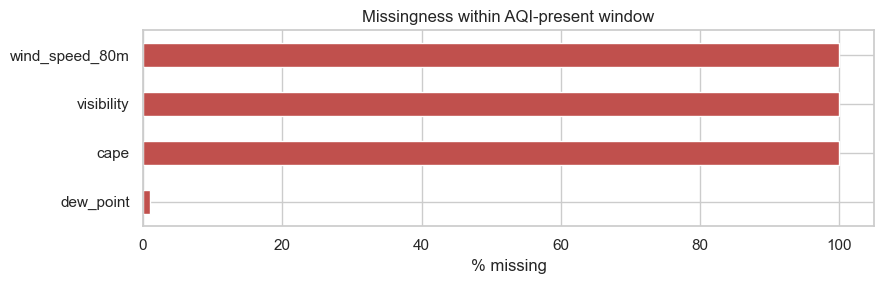

Variables fully populated in the AQI window: ['AQI', 'CO', 'Humidity', 'NO2', 'O3', 'PM10', 'Precipitation', 'SO2', 'Temperature', 'PM2_5', 'wind_direction', 'wind_speed', 'apparent_temp', 'surface_pressure', 'wind_gusts', 'BLH', 'aod', 'cloud_cover', 'dust', 'shortwave_rad', 'uv_index']


In [5]:
# Missingness within the AQI-present window (true gaps, not the weather-only backfill era).
miss = (dfa[obs_num].isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(miss))))
if len(miss):
    miss.plot.barh(ax=ax, color="#c0504d")
    ax.invert_yaxis()
ax.set_xlabel("% missing"); ax.set_title("Missingness within AQI-present window")
plt.tight_layout(); plt.show()
print("Variables fully populated in the AQI window:",
      [c for c in obs_num if dfa[c].notna().all()])

## 4. Target variable — AQI distribution
US-AQI scale with EPA category bands. Karachi air quality is right-skewed: many moderate days punctuated by pollution spikes.

count    1396.00
mean       91.03
std        30.05
min        15.50
25%        69.20
50%        82.26
75%       104.76
max       214.62

Skewness: 1.17   Kurtosis: 1.04


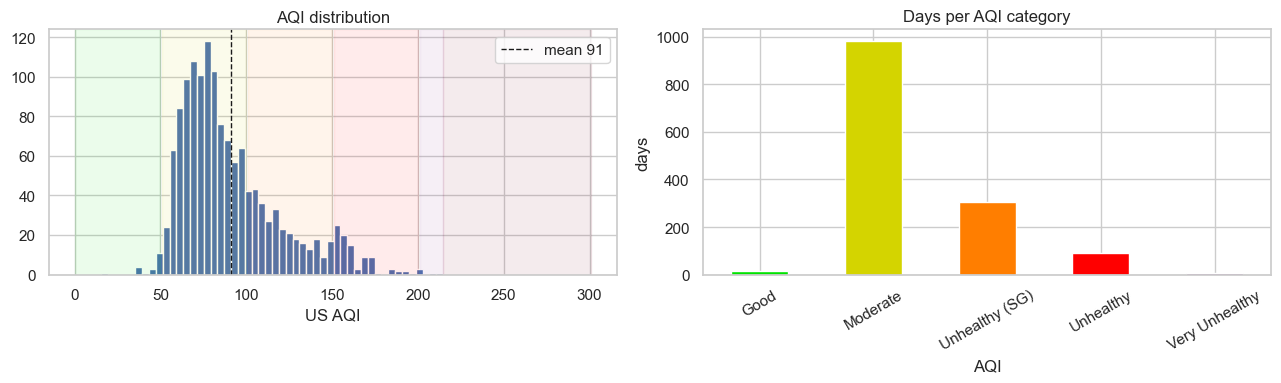

In [6]:
aqi = dfa["AQI"].dropna()
print(aqi.describe().round(2).to_string())
print(f"\nSkewness: {aqi.skew():.2f}   Kurtosis: {aqi.kurtosis():.2f}")

BANDS = [(0,50,"Good","#00e400"),(51,100,"Moderate","#d4d400"),
         (101,150,"Unhealthy (SG)","#ff7e00"),(151,200,"Unhealthy","#ff0000"),
         (201,300,"Very Unhealthy","#8f3f97"),(301,500,"Hazardous","#7e0023")]

def band(v):
    for lo, hi, lab, col in BANDS:
        if v <= hi:
            return lab
    return "Hazardous"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.hist(aqi, bins=50, color="#4c72b0", edgecolor="white")
for lo, hi, lab, col in BANDS:
    ax1.axvspan(lo, min(hi, aqi.max()), color=col, alpha=0.08)
ax1.axvline(aqi.mean(), color="k", ls="--", lw=1, label=f"mean {aqi.mean():.0f}")
ax1.set_title("AQI distribution"); ax1.set_xlabel("US AQI"); ax1.legend()

cat = aqi.apply(band).value_counts()
order = [b[2] for b in BANDS]
cat = cat.reindex([o for o in order if o in cat.index])
colors = {b[2]: b[3] for b in BANDS}
cat.plot.bar(ax=ax2, color=[colors[i] for i in cat.index])
ax2.set_title("Days per AQI category"); ax2.set_ylabel("days")
ax2.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 5. AQI over time

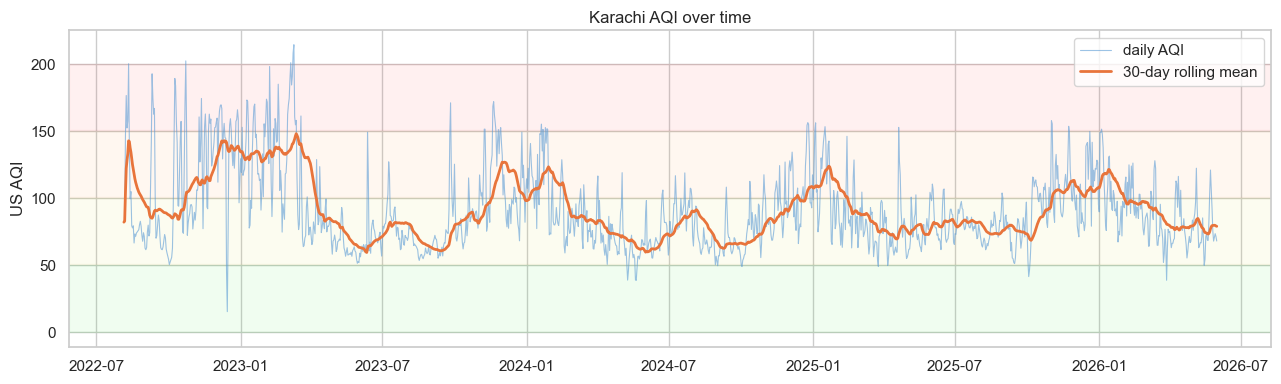

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dfa["date"], dfa["AQI"], color="#5b9bd5", lw=0.8, alpha=0.6, label="daily AQI")
ax.plot(dfa["date"], dfa["AQI"].rolling(30, min_periods=1).mean(),
        color="#e8743b", lw=2, label="30-day rolling mean")
for lo, hi, lab, col in BANDS[:4]:
    ax.axhspan(lo, hi, color=col, alpha=0.06)
ax.set_title("Karachi AQI over time"); ax.set_ylabel("US AQI"); ax.legend()
plt.tight_layout(); plt.show()

## 6. Stationarity (ADF test)
Augmented Dickey-Fuller on the daily AQI series (gaps filled by time interpolation).

In [8]:
from statsmodels.tsa.stattools import adfuller

s = dfa.set_index("date")["AQI"].asfreq("D").interpolate("time")
stat, p, *_ = adfuller(s.dropna())
print(f"ADF statistic : {stat:.3f}")
print(f"p-value       : {p:.4g}")
print("=> stationary (reject unit root)" if p < 0.05 else "=> non-stationary")

ADF statistic : -5.256
p-value       : 6.741e-06
=> stationary (reject unit root)


## 7. Autocorrelation (ACF / PACF)
How far AQI 'remembers' its past — this sets a rough ceiling on how predictable each forecast horizon is (R^2 cannot exceed ACF^2 for a pure persistence signal).

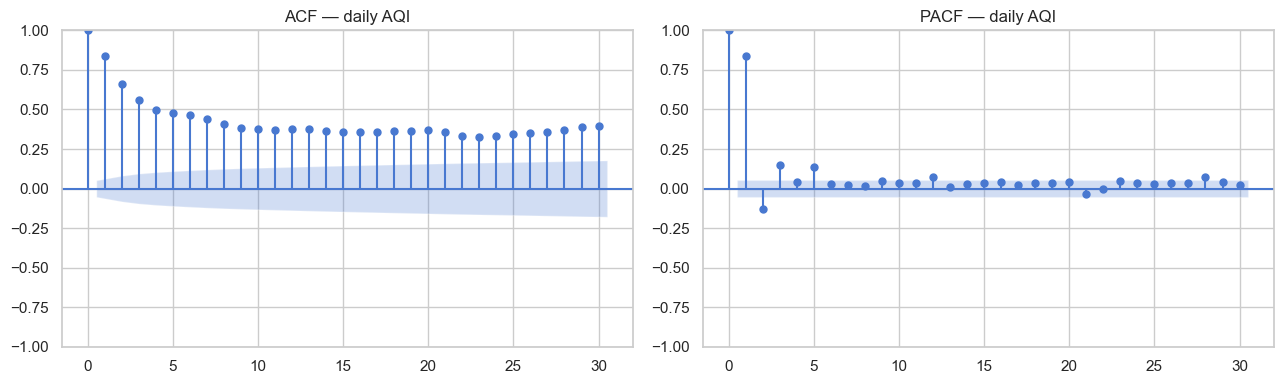

Autocorrelation & rough R^2 ceiling (ACF^2) by forecast horizon:
  +1 day : ACF=0.836   R^2 ceiling ~ 0.698
  +2 day : ACF=0.660   R^2 ceiling ~ 0.435
  +3 day : ACF=0.560   R^2 ceiling ~ 0.313


In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(s.dropna(), lags=30, ax=ax1);  ax1.set_title("ACF — daily AQI")
plot_pacf(s.dropna(), lags=30, ax=ax2, method="ywm");  ax2.set_title("PACF — daily AQI")
plt.tight_layout(); plt.show()

a = acf(s.dropna(), nlags=3)
print("Autocorrelation & rough R^2 ceiling (ACF^2) by forecast horizon:")
for h in (1, 2, 3):
    print(f"  +{h} day : ACF={a[h]:.3f}   R^2 ceiling ~ {a[h]**2:.3f}")

## 8. Seasonal decomposition
Additive decomposition with a 365-day period separates the long-run trend, the annual seasonal cycle, and the residual.

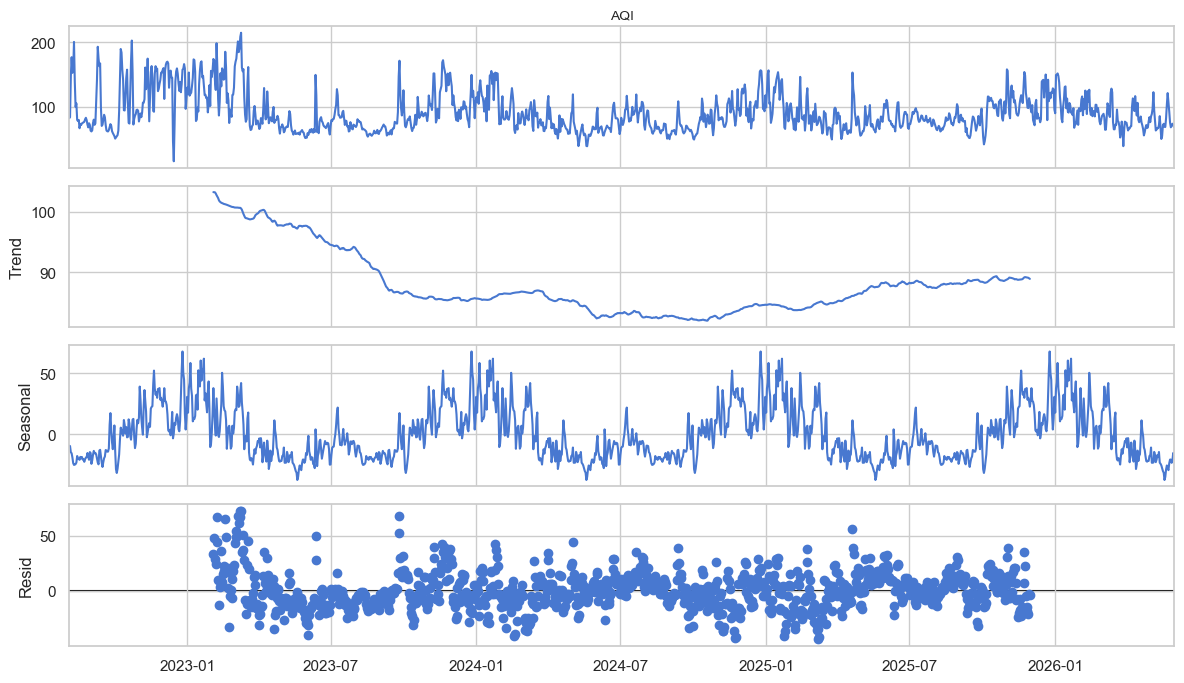

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

dec = seasonal_decompose(s.interpolate("time").dropna(), period=365, model="additive")
fig = dec.plot(); fig.set_size_inches(12, 7)
for a_ in fig.axes:
    a_.set_title(a_.get_title(), fontsize=10)
plt.tight_layout(); plt.show()

## 9. Seasonality patterns
Mean AQI by month, meteorological season, and day of week.

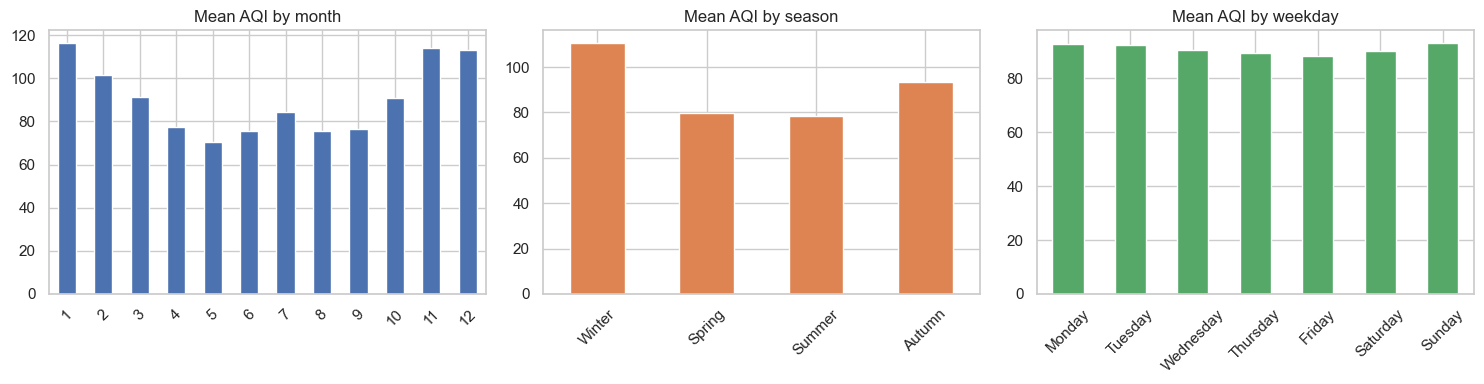

         mean   std    max
season                    
Autumn   93.6  31.6  202.5
Spring   79.8  25.9  214.6
Summer   78.3  18.9  200.4
Winter  110.6  29.1  198.4


In [11]:
SEASON = {12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",
          6:"Summer",7:"Summer",8:"Summer",9:"Autumn",10:"Autumn",11:"Autumn"}
d = dfa.dropna(subset=["AQI"]).copy()
d["month"]   = d["date"].dt.month
d["season"]  = d["month"].map(SEASON)
d["weekday"] = d["date"].dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
d.groupby("month")["AQI"].mean().plot.bar(ax=axes[0], color="#4c72b0")
axes[0].set_title("Mean AQI by month")
sea = d.groupby("season")["AQI"].mean().reindex(["Winter","Spring","Summer","Autumn"])
sea.plot.bar(ax=axes[1], color="#dd8452"); axes[1].set_title("Mean AQI by season")
wk = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
d.groupby("weekday")["AQI"].mean().reindex(wk).plot.bar(ax=axes[2], color="#55a868")
axes[2].set_title("Mean AQI by weekday")
for ax in axes:
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print(d.groupby("season")["AQI"].agg(["mean","std","max"]).round(1).to_string())

## 10. Pollutant & weather distributions

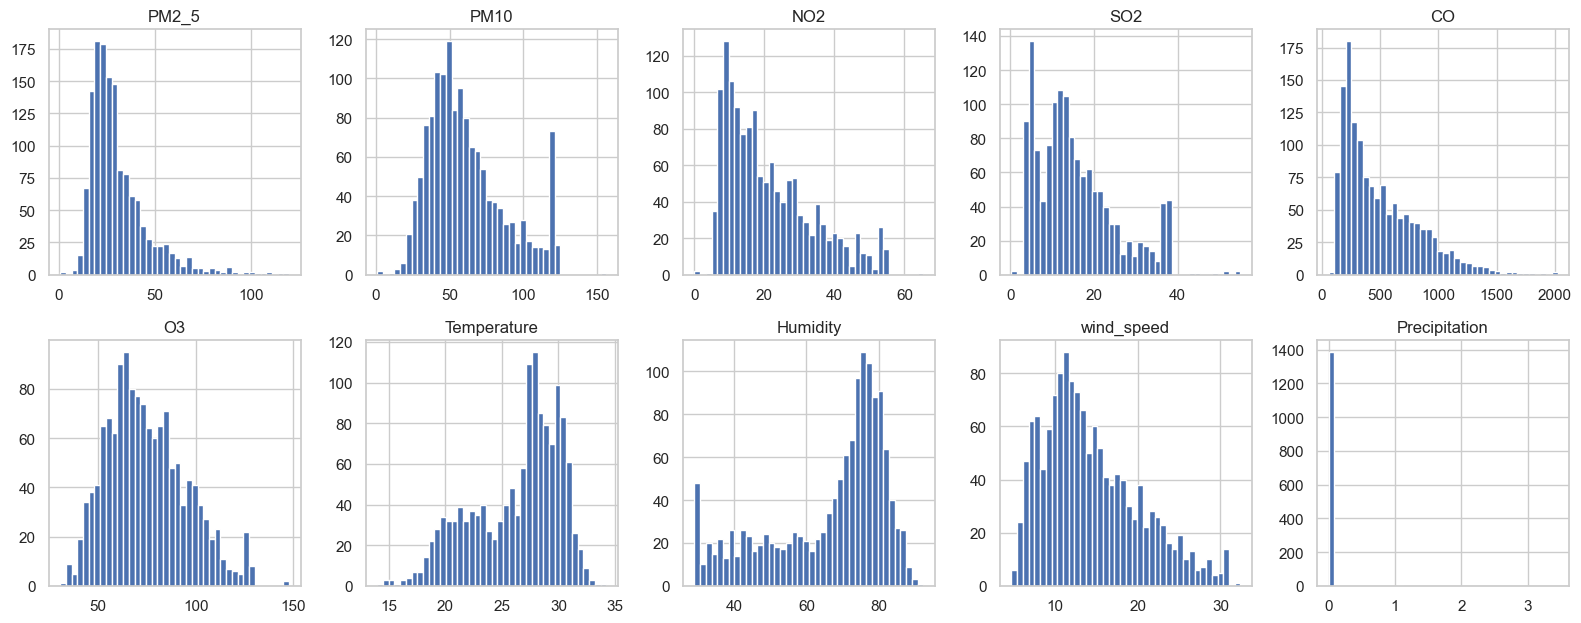

In [12]:
show = [c for c in ["PM2_5","PM10","NO2","SO2","CO","O3",
                    "Temperature","Humidity","wind_speed","Precipitation"]
        if c in dfa.columns]
n = len(show); ncols = 5; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
for ax, c in zip(axes.ravel(), show):
    dfa[c].dropna().hist(bins=40, ax=ax, color="#4c72b0", edgecolor="white")
    ax.set_title(c)
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 11. Correlations among observed variables
Same-day (contemporaneous) relationships — an unbiased view of which measurements move with AQI.

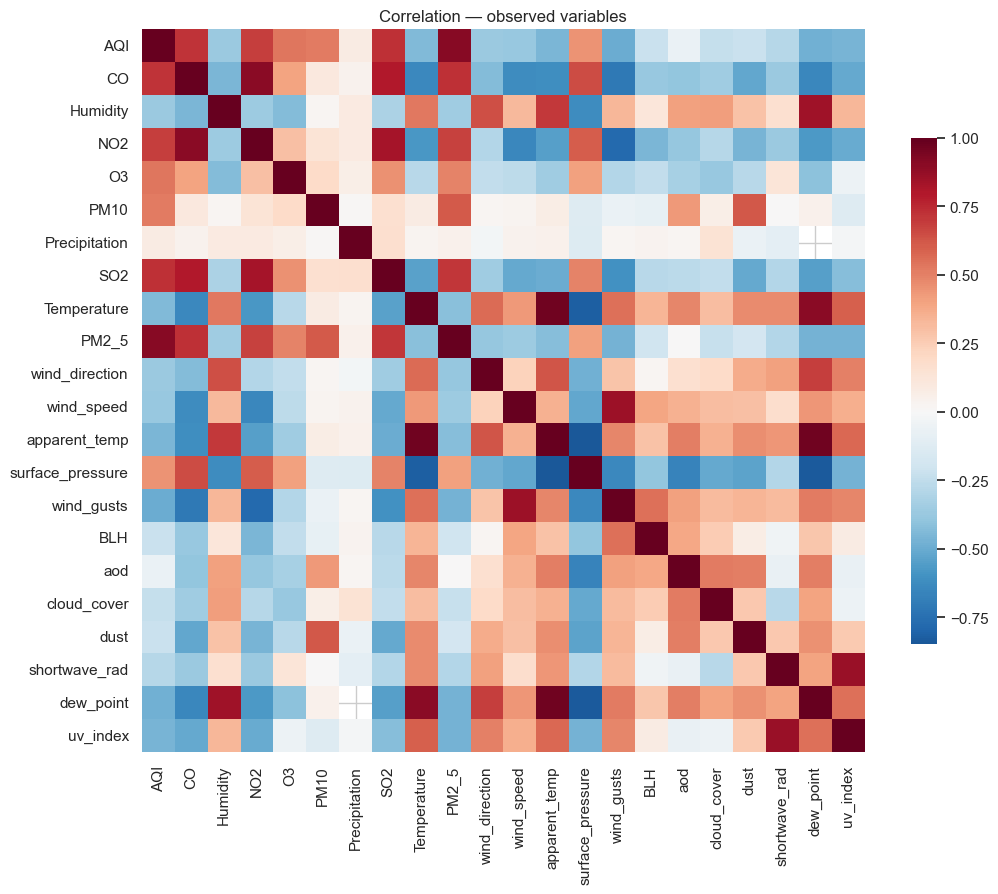

Correlation of observed variables with same-day AQI:
PM2_5               0.909
SO2                 0.728
CO                  0.720
NO2                 0.687
O3                  0.539
PM10                0.523
wind_gusts         -0.496
dew_point          -0.483
uv_index           -0.462
apparent_temp      -0.451
surface_pressure    0.445
Temperature        -0.440
wind_speed         -0.378
wind_direction     -0.372
Humidity           -0.366
shortwave_rad      -0.286
cloud_cover        -0.234
dust               -0.223
BLH                -0.222
Precipitation       0.080
aod                -0.060


In [13]:
corr_cols = [c for c in observed if pd.api.types.is_numeric_dtype(dfa[c])
             and dfa[c].notna().sum() > len(dfa) * 0.5]
corr = dfa[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Correlation — observed variables")
plt.tight_layout(); plt.show()

with_aqi = corr["AQI"].drop("AQI").sort_values(key=abs, ascending=False)
print("Correlation of observed variables with same-day AQI:")
print(with_aqi.round(3).to_string())

## 12. Key relationships with AQI

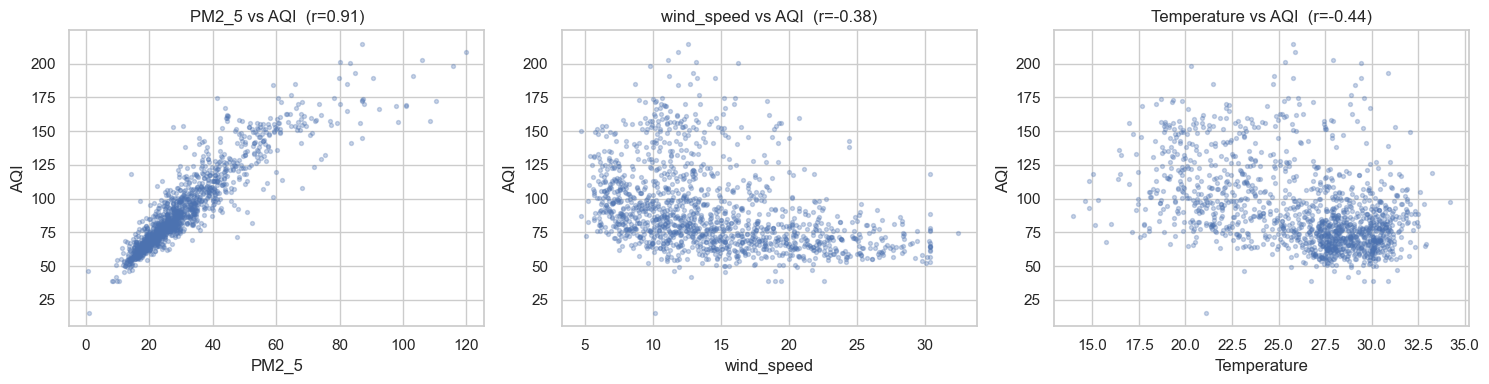

In [14]:
pairs = [c for c in ["PM2_5", "wind_speed", "Temperature"] if c in dfa.columns]
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))
if len(pairs) == 1:
    axes = [axes]
for ax, c in zip(axes, pairs):
    sub = dfa[[c, "AQI"]].dropna()
    ax.scatter(sub[c], sub["AQI"], s=8, alpha=0.3, color="#4c72b0")
    r = sub[c].corr(sub["AQI"])
    ax.set_xlabel(c); ax.set_ylabel("AQI"); ax.set_title(f"{c} vs AQI  (r={r:.2f})")
plt.tight_layout(); plt.show()

## 13. Summary

In [15]:
worst_season = sea.idxmax()
top_corr     = with_aqi.index[0]
unhealthy    = (aqi > 100).mean() * 100

print("EDA SUMMARY")
print("-" * 52)
print(f"AQI observations        : {len(dfa):,} days "
      f"({dfa['date'].min().date()} -> {dfa['date'].max().date()})")
print(f"Mean AQI                : {aqi.mean():.0f}  ({band(aqi.mean())})")
print(f"Median AQI              : {aqi.median():.0f}")
print(f"Days AQI>100 (unhealthy): {unhealthy:.0f}%")
print(f"Worst season            : {worst_season}  ({sea.max():.0f} avg AQI)")
print(f"ACF +1 day / +3 day     : {a[1]:.2f} / {a[3]:.2f}")
print(f"Strongest AQI correlate : {top_corr}  (r={with_aqi.iloc[0]:.2f})")

EDA SUMMARY
----------------------------------------------------
AQI observations        : 1,396 days (2022-08-05 -> 2026-05-31)
Mean AQI                : 91  (Moderate)
Median AQI              : 82
Days AQI>100 (unhealthy): 29%
Worst season            : Winter  (111 avg AQI)
ACF +1 day / +3 day     : 0.84 / 0.56
Strongest AQI correlate : PM2_5  (r=0.91)
